# Preliminaries

In [1]:
!pip install SimpleITK numpy matplotlib
!pip install --upgrade git+https://github.com/pyushkevich/upenn_be5370_utils.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 13.5 MB/s eta 0:00:00
  Cloning https://github.com/pyushkevich/upenn_be5370_utils.git to /tmp/pip-req-build-vi7eoiri
  Running command git clone --filter=blob:none --quiet https://github.com/pyushkevich/upenn_be5370_utils.git /tmp/pip-req-build-vi7eoiri
  Resolved https://github.com/pyushkevich/upenn_be5370_utils.git to commit 801c634d57f426a21c3a23762c332bdef43459a8
  Preparing metadata (setup.py) ... done
  Created wheel for upenn_be5370_utils: filename=upenn_be5370_utils-0.2-py3-none-any.whl size=11259 sha256=e694f3bc3a9b52694c8f8d4fe4fc60a7bf8d848414a585314c23ad9e095da87d
  Stored in directory: /tmp/pip-ephem-wheel-cache-48r4ayix/wheels/db/a8/d2/9e840877c2229dcd0d9c6e480b8829849c2ad13628794b0f75
Successfully built upenn_be5370_utils


In [2]:
# Import the libraries we need
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import SimpleITK as sitk
import pandas as pd
import matplotlib.pyplot as plt
import time

# Import our libraries
from upenn_be5370_utils.sitkview import view_sitk
from upenn_be5370_utils.transforms import *


Mounted at /content/drive


In [3]:
# Root directory for the dataset
root = '/content/drive/MyDrive/Colab Notebooks/Registration/data'

# Fixed and moving images (change these to an arbitrary pair of subject ids)
id_fix, id_mov = 1006, 1012
# id_fix, id_mov = 1009, 1015

# Step 1. 3D Images in PyTorch

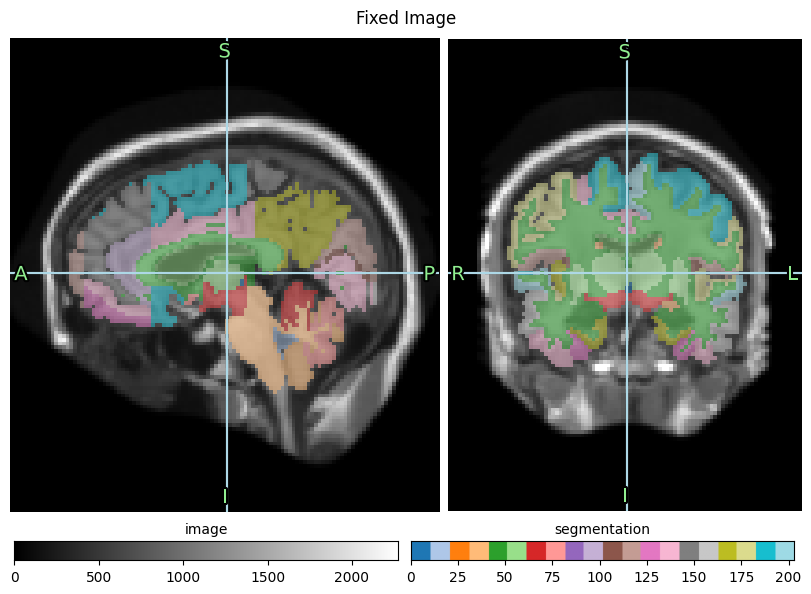

In [4]:
try:
    img = sitk.ReadImage(f'{root}/images/atlas_2mm_{id_fix}_3.nii.gz')

    # Read segmentation image
    seg = sitk.ReadImage(f'{root}/images/atlasseg_2mm_{id_fix}_3.nii.gz')

    # Show the image and the segmentation
    view_sitk(img, seg, cmap=['gray','tab20'], name=['image', 'segmentation'], width=8, title='Fixed Image');

except RuntimeError as e:
    print(f"Error reading image: {e}")
    print("Please ensure the data files are correctly placed in the specified root directory.")
    print(f"Attempted to read: {root}/images/atlas_2mm_{id_fix}_3.nii.gz")

## Task 1A. 

  -  Most PyTorch routines that work with 3D arrays will expect their inputs to have **five** dimensions, denoted in the PyTorch documentation as `[B,C,D,H,W]`, where `B` is the mini-batch size, `C` is the number of channels/components, and `DxHxW` are the dimensions of the 3D array (depth, height, width).
  
  - However, when describing spatial transformations, PyTorch uses a different format, described in the documentation of `torch.nn.functional.grid_sample`. A 3D spatial transformation, or warp, is encoded as a tensor of shape `[B,D,H,W,3]`, where the last dimension is used to store 3-dimensional displacement vectors in each voxel of the image.
  
  - Functions are able to map between PyTorch and SimpleITK for three types of images:

    - 3D scalar images should map to [1,1,D,H,W] tensors
  
    - 3D spatial transformations should map to [B,D,H,W,3] tensors (`is_warp=True`)
  
    - Other 3D multi-component images should map to [1,C,D,H,W] tensors (`is_warp=False`)

  - When writing these functions, here are some hints:
  
    - We want the user of `my_sitk_to_torch` to be able to pass arguments to the PyTorch tensor creation routines (e.g., `torch.tensor`), including data type (`dtype`), device (`device`) and whether to compute/retain the gradient of the tensor during back-propagation (`needs_grad`). To pass these arguments to PyTorch when creating a tensor, write `torch.tensor(..., **kwargs)`
        
    - Use `sitk.GetArrayFromImage` and `sitk.GetImageFromArray` functions to get arrays in and out of the ITK image.

    - Use `sitk.Image.GetNumberOfComponentsPerPixel` to tell apart scalar and multi-component images.apart
    
    - Use `sitk.Image.CopyInformation` to update the header of the output image in `my_torch_to_sitk` based on the header of the reference image.
        
    - To reorder the dimensions in a tensor, use `tensor.permute()`

    - To get a NumPy array with the contents of a PyTorch tensor `T`, use `T.detach().cpu().numpy()`


In [5]:
def my_sitk_to_torch(img, is_warp=False, **kwargs):
    """
    Convert 3D SimpleITK image to PyTorch 5D tensor. Supports scalar images
    and vector (multi-component) images.

    Args:
        img:
            SimpleITK image, 3D scalar or vector image
        is_warp:
            Boolean, indicates whether multi-component images should be treated as
            spatial transformations [1,D,H,W,3] or multi-channel images [1,C,D,H,W]
        dtype, device:
            These parameters will be passed on to torch.tensor()
    Output:
        A torch tensor holding the voxel data
    """

    # Convert SITK to numpy array
    arr = sitk.GetArrayFromImage(img)                       # pull voxel data out of the SITK image as a NumPy array
    arr = np.ascontiguousarray(arr)
    n_comp = int(img.GetNumberOfComponentsPerPixel())       # how many values per voxel (scalar if ==1, warp is everything else)

    # scalar image
    if n_comp == 1:

        # Scalar: [D,H,W] to [1,1,D,H,W]
        arr = arr[None, None, ...]                          # batch, channel
    else:                                                   # everything else
        if is_warp:
            # Warp: [D,H,W,3] to [1,D,H,W,3]
            if arr.shape[-1] != 3:
                raise ValueError("Warp images must have 3 components per voxel.")
            arr = arr[None, ...]
        else:
            # Multi-channel: [D,H,W,C] to [1,C,D,H,W]
            arr = np.moveaxis(arr, -1, 0)
            arr = arr[None, ...]

    return torch.tensor(arr, **kwargs)                      # NumPy array as a torch tensor


def my_torch_to_sitk(T, ref, is_warp=False):
    """
    Convert a PyTorch 5D tensor to a 3D SimpleITK image. Supports scalar images
    and vector (multi-component) images.

    Args:
        T:
            A 5-D tensor representing a scalar 3D image [1,1,D,H,W], a multi-channel
            3D image [1,C,D,H,W], or or a 3D spatial transformation [1,D,H,W,3]
        ref:
            Reference 3D image, a SimpleITK image from which the metadata including
            spacing, origin, and direction matrix will be assigned to the output image.
        is_warp:
            Boolean, indicates if the tensor represents a spatial transformation. If so,
            the tensor is expected to have shape [1,D,H,W,3].

    Output:
        A SimpleITK image.
    """

    t = T.detach().cpu()

    # Warp field: [1, D, H, W, 3] to [D, H, W, 3]
    if is_warp:
        arr = t[0].numpy()                                    # remove batch dimension and convert to NumPy
        arr = np.ascontiguousarray(arr)
        out = sitk.GetImageFromArray(arr, isVector=True)

    else:

        if t.shape[1] == 1:
            # Scalar: [1,1,D,H,W] to [D,H,W]
            arr = t[0, 0].numpy()
            arr = np.ascontiguousarray(arr)
            out = sitk.GetImageFromArray(arr, isVector=False)

        else:
            # Multi channel: [1,C,D,H,W] to [D,H,W,C]
            arr = t[0].permute(1, 2, 3, 0).numpy()
            arr = np.ascontiguousarray(arr)
            out = sitk.GetImageFromArray(arr, isVector=True)


    out.CopyInformation(ref)
    return out                                                # return constructed image

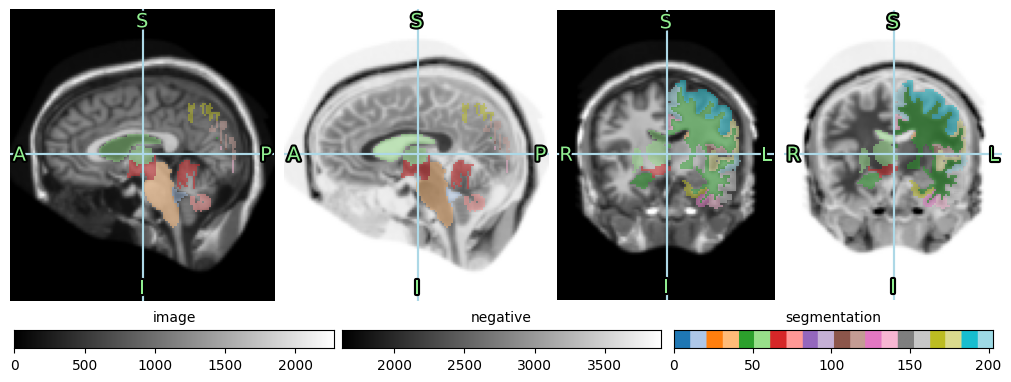

In [6]:
# Compute the negative image
T_img = my_sitk_to_torch(img, dtype=torch.float32)
T_neg = torch.max(T_img) - T_img
img_neg = my_torch_to_sitk(T_neg, img)

# Remove all odd labels in the segmentation
T_seg = my_sitk_to_torch(seg, dtype=torch.int16)
T_seg_even = torch.where(T_seg % 2 == 1, T_seg, torch.zeros_like(T_seg))
seg_even = my_torch_to_sitk(T_seg_even, img)

# Show result
view_sitk(img, img_neg, seg_even, layout='tto', cmap=['gray','gray','tab20'],
          name=['image', 'negative', 'segmentation'], width=10);

## Task 1B. Use PyTorch to Report Statistics

Report of volume and mean MRI intensity for labels 31 (right amygdala), 32 (left amygdala), 47 (right hippocampus), 48 (left hippocampus), 51 (right lateral ventricle) and 52 (left lateral ventricle).

<p style="text-align: center;"><img width="40%" src="https://raw.githubusercontent.com/pyushkevich/upenn_be5370_utils/main/doc/figs/rp1/snap_volstat.png"></img><br>Volumes and Intensity Statistics window in ITK-SNAP</p>


,Label,Structure,Volume (mm^3),Mean Intensity
0,31,Right Amygdala,992.0,1015.242
1,32,Left Amygdala,928.0,1020.474
2,47,Right Hippocampus,"4,024.0",1027.921
3,48,Left Hippocampus,"4,056.0",1017.199
4,51,Right Lateral Ventricle,"15,352.0",515.334
5,52,Left Lateral Ventricle,"16,616.0",504.800


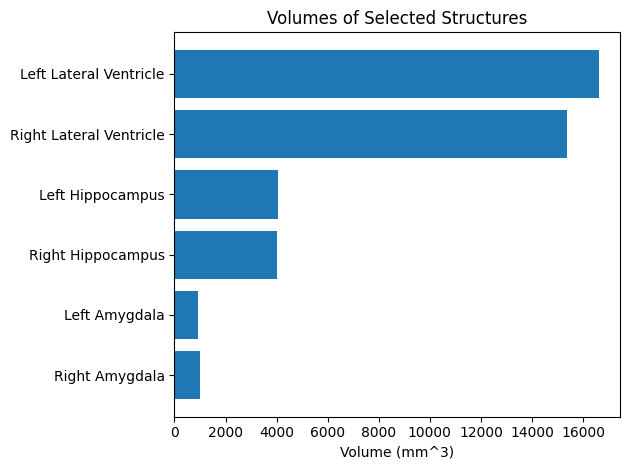

In [7]:
# Define the labels we want to report
labels = {
    31: 'Right Amygdala',
    32: 'Left Amygdala',
    47: 'Right Hippocampus',
    48: 'Left Hippocampus',
    51: 'Right Lateral Ventricle',
    52: 'Left Lateral Ventricle',
}


T_img = my_sitk_to_torch(img, dtype=torch.float32)                        # [1,1,D,H,W]
T_seg = my_sitk_to_torch(seg, dtype=torch.int64)                          # [1,1,D,H,W]

I = T_img[0, 0]                                                           # intensity
S = T_seg[0, 0]                                                           # segmentation

# Voxel volume in mm^3
sx, sy, sz = img.GetSpacing()                                             # x,y,z in mm
voxel_vol_mm3 = torch.tensor(sx * sy * sz, dtype=torch.float32)           # convert voxel size (mm) to a PyTorch tensor

# Collect stats
rows = []
for lab, name in labels.items():                                          # loop through structures listed above ^
    mask = (S == lab)                                                     # create mask for structure [D,H,W]
    count = mask.sum()                                                    # count number of voxels in structure
    vol_mm3 = count.to(torch.float32) * voxel_vol_mm3                     # voxel count to volume

    # mean intensity for the structure
    sum_int = (I * mask) .sum()
    mean_int = torch.where(count > 0, sum_int / count.to(sum_int.dtype),
                           torch.tensor(float('nan')))
    rows.append((lab, name, vol_mm3.item(), mean_int.item()))

# results

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(rows, columns=["Label", "Structure", "Volume (mm^3)", "Mean Intensity"])
display(df.style.format({"Volume (mm^3)": "{:,.1f}", "Mean Intensity": "{:.3f}"}))

plt.figure()
plt.barh(df["Structure"], df["Volume (mm^3)"])
plt.xlabel("Volume (mm^3)")
plt.title("Volumes of Selected Structures")
plt.tight_layout()
plt.show()

### Comparing PyTorch and ITK results

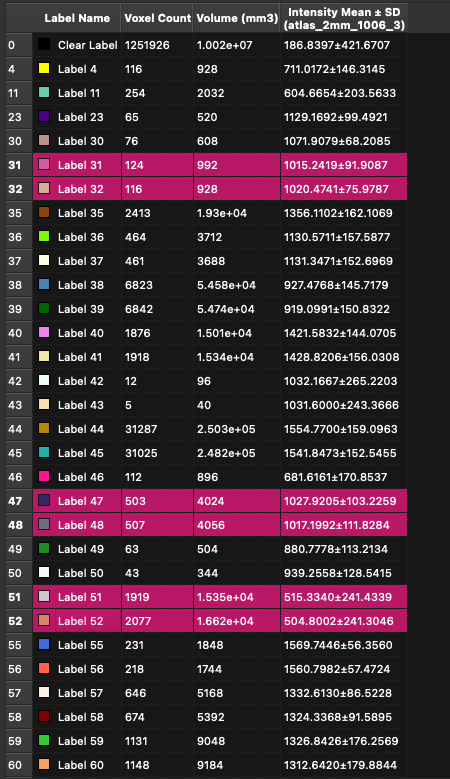

# **Results:** PyTorch and ITK results match

## Task 1C. Implement the Sobel Filter in PyTorch.

The Sobel filter is one of the simplest filters for edge detection. We don't really care about edge detection per se in this assignment, but it is a good way to play with some PyTorch tensor features. In two dimensions, the Sobel operators in the $x$ and $y$ direction have the form of $3 \times 3$ matrices below:

$$
S_x =
\begin{bmatrix}
+1 & 0 & -1 \\
+2 & 0 & -2 \\
+1 & 0 & -1 \\
\end{bmatrix}
\qquad
S_y =
\begin{bmatrix}
+1 & +2 & +1 \\
0 & 0 & 0 \\
-1 & -2 & -1 \\
\end{bmatrix}
$$

Convolution between an image and the Sobel operator $S_x$ gives an approximation of the partial derivative of the image intensity in the $x$ direction, likewise for $y$. So convolving the image with both $S_x$ and $S_y$ and storing the results in different channels gives us an approximation of the image gradient. Same is true for 3D, and this [Wikipedia article on the Sobel operator](https://en.wikipedia.org/wiki/Sobel_operator) gives a good explanation of the 2D Sobel operator and its extension to 3D.

<p style="text-align: center;"><img width="60%" src="https://raw.githubusercontent.com/pyushkevich/upenn_be5370_utils/main/doc/figs/rp1/snap_sobel.png"></img><br>Sobel filter computed in PyTorch for an MRI scan</p>


(<Figure size 800x311.509 with 6 Axes>,
 [[<Axes: >, <Axes: >], [<Axes: >, <Axes: >]])

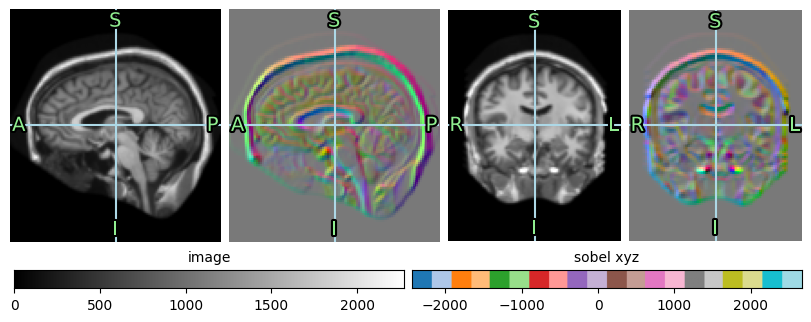

In [8]:
# Convert MRI to Pytorch
T = my_sitk_to_torch(img, dtype=torch.float32)          # input image

# 1D Sobel pieces
s = torch.tensor([1., 2., 1.], device=T.device, dtype=T.dtype)   # Smooth neighboring values so the derivative is stable (smooth)
d = torch.tensor([1., 0., -1.], device=T.device, dtype=T.dtype)  # Detect how intensity goes up/down (derivative)

# compute 3D gradient
kx = torch.einsum('a,b,c->abc', s, s, d)
ky = torch.einsum('a,b,c->abc', s, d, s)
kz = torch.einsum('a,b,c->abc', d, s, s)

# Stack the 3 kernels into one tensor
weight = torch.stack([kz, ky, kx], dim=0).unsqueeze(1) / 8.0  # dividing by 8 scales the Sobel kernel (2*2*2)

G = torch.nn.functional.conv3d(T, weight, padding='same')

# Convert the result of convolution to a SimpleITK multi-component image and display
grad_sitk = my_torch_to_sitk(G, img, is_warp=False)
view_sitk(img, grad_sitk, layout='tto', cmap=['gray', 'tab20'],
          name=['image', 'sobel xyz'], width=8)

# Step 2. Perform Registration in ITK-SNAP\
\

<p style="text-align: center;"><img width="70%" src="https://raw.githubusercontent.com/pyushkevich/upenn_be5370_utils/main/doc/figs/rp1/snap_registration.png"></img><br>Registration between two images in ITK-SNAP</p>


Among the available automatic registration settings, the rigid-body registration with mutual information provided the most accurate alignment between the structural and reference scans. This setting effectively handled small rotations and translations without distorting the anatomy. Compared to manual registration the automatic method achieved better overlap of key brain structures such as ventricles and cortical boundaries. Overall, the automatic registration was both efficient and precise, significantly reducing the time needed for manual adjustments.

https://drive.google.com/file/d/1w8gOSCL0TWbE8qPWQncKFA2UTC13y0uB/view?usp=sharing

## Step 3. Implement Affine Transformations and Reslicing in PyTorch

In [9]:
def my_transform_image_pytorch(T_ref, T_mov, A, b,
                               mode='bilinear', padding_mode='zeros'):
    """
    Apply an affine transform to 3D moving image and reslice it into the space of the
    fixed (reference) image.

    Args:
        T_ref:
            Fixed (reference) image, a shape (1,Cf,Df,Hf,Wf) tensor
        T_mov:
            Moving image, represented a shape (1,Cm,Dm,Hm,Wm) tensor
        A:
            Affine transformation matrix in PyTorch coordinate space, a shape (3,3) tensor
        b:
            Translation vector in PyTorch coordinate space, a shape (3) tensor
        mode:
            Interpolation mode, see documentation for `grid_sample`
        padding_mode:
            Padding mode, see documentation for `grid_sample`

    Output:
        Moving image transformed and resliced into reference image space,
        a shape (1,Cm,Df,Hf,Wf) tensor
    """
    # Combine A and b into PyTorch transformation tensor
    theta = torch.cat([A, b.view(3,1)], dim=1).unsqueeze(0)

    # Build sampling grid
    grid = torch.nn.functional.affine_grid(theta, T_ref.shape, align_corners=True)

    # Apply the transformation to moving image
    T_transformation = torch.nn.functional.grid_sample(T_mov, grid, mode=mode, padding_mode=padding_mode, align_corners=True)

    return T_transformation

Transform parameters in SimpleITK: (0.999672, -0.0255552, 0.00168592, 0.0254241, 0.998168, 0.0549103, -0.00308607, -0.0548495, 0.99849), (-0.589231, -4.81141, 4.63309)
Transform parameters in PyTorch: [ 0.999672   -0.0308792  -0.00224789  0.02104063  0.998168   -0.06059068
  0.00231455  0.04970736  0.99849   ], [0.00638304 0.04123927 0.03577982]


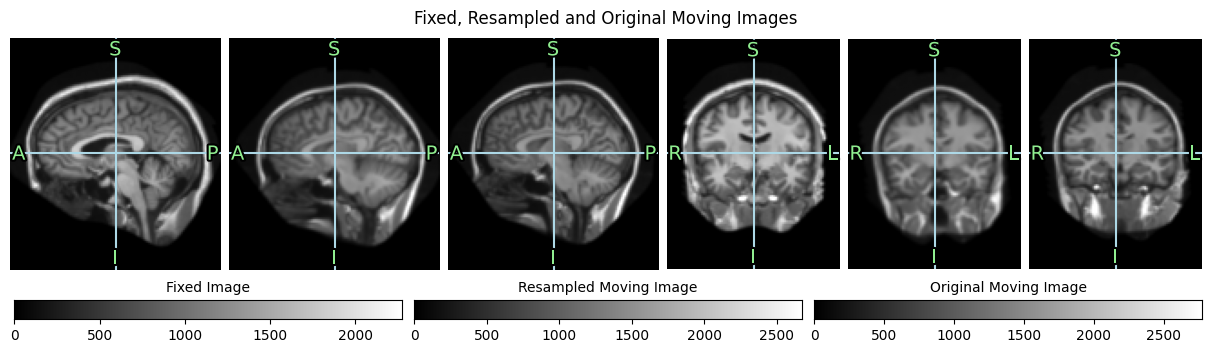

In [10]:
# Load the fixed and moving images
img_fix = sitk.ReadImage(f'{root}/images/atlas_2mm_{id_fix}_3.nii.gz')
img_mov = sitk.ReadImage(f'{root}/images/atlas_2mm_{id_mov}_3.nii.gz')

# Map to tensors
T_fix, T_mov = (my_sitk_to_torch(x, dtype=torch.float32) for x in (img_fix, img_mov))

# Load the transform into an sitk object (replace the filename with yours)
tran_itk = load_itksnap_transform(f'{root}/snap_affine_transform_fx{id_fix}_mv{id_mov}.mat')
print(f'Transform parameters in SimpleITK: {tran_itk.GetMatrix()}, {tran_itk.GetTranslation()}')

# Convert to the format compatible with affine_grid
A, b = map_affine_sitk_to_pytorch(tran_itk, img_fix, img_mov)
T_A, T_b = (torch.tensor(x, dtype=torch.float32) for x in (A,b))
print(f'Transform parameters in PyTorch: {A.flatten()}, {b}')

# Apply transformation
T_resampled = my_transform_image_pytorch(T_fix, T_mov, T_A, T_b)
img_resampled = my_torch_to_sitk(T_resampled, img_fix)

# Visualize the result
view_sitk(img_fix, img_resampled, img_mov,
          name=['Fixed Image','Resampled Moving Image','Original Moving Image'],
          layout='ttt', width=12, cmap='gray', title='Fixed, Resampled and Original Moving Images');

# Step 4. Function to Parameterize Rotations

From the Rigid and Affine Registration module, in the Rotations pdf, the approach we have chosen is the **Axis-Angle Representation + the Rodriguez formula** where the 3-vector input (x = Θu) is a rotation that has magnitude (θ) = ||x|| is the rotation angle and its direction (u = x/|x|) specifies the direction of the rotation axis. The corresponding rotation matrix is obtained using the Rodrigues formula, using the skew-symmetric matrix U built from u:

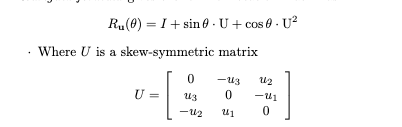



In [11]:
def my_rotation_from_vector(x):
    """
    Generate a 3D rotation vector from three parameters.

    Args:
        x:
            A torch tensor of shape (3). It contains the parameters of the rotation.
            [Write more detail about what the parameters mean geometrically]
    Output:
        A shape (3,3) tensor holding a rotation matrix corresponding to x
    """
    #rodrigues formula
    #compute rotation angle
    theta = torch.norm(x)
    #avoid division by zero
    if theta < 1e-8:
        return torch.eye(3, dtype=x.dtype, device=x.device)
    #Normalize rotation axis
    k = x / theta  # unit vector
    #skew-symmetric matrix [k]_x
    K = torch.tensor([
        [0, -k[2], k[1]],
        [k[2], 0, -k[0]],
        [-k[1], k[0], 0]
    ], dtype=x.dtype, device=x.device)
    #R = I + sinθ [k]_x + (1 - cosθ) [k]_x^2
    R = torch.eye(3, dtype=x.dtype, device=x.device) + \
        torch.sin(theta) * K + \
        (1 - torch.cos(theta)) * (K @ K)

    return R

The code below checks that your computation returns actual rotation matrices, i.e. ones that satisfy $R^t R = I$. You should see values very close to zero in the last column.

In [12]:
x_check = [ torch.zeros(3) ] + [ torch.rand(3) for i in range(5) ]
for x in x_check:
    R = my_rotation_from_vector(x)
    print(f'Parameters: {x.detach().cpu().numpy()}, |R^T @ R - I| = {torch.det(R.T @ R - torch.eye(3)).item()}')

Parameters: [0. 0. 0.], |R^T @ R - I| = 0.0
Parameters: [0.62067306 0.93900084 0.6333684 ], |R^T @ R - I| = -0.0
Parameters: [0.5528342  0.26852208 0.20181668], |R^T @ R - I| = 1.6543613828782364e-23
Parameters: [0.6379307  0.34584576 0.2874998 ], |R^T @ R - I| = -0.0
Parameters: [0.6807362 0.7766969 0.4452874], |R^T @ R - I| = 4.235164736271502e-22
Parameters: [0.26921374 0.4627686  0.8917417 ], |R^T @ R - I| = 3.308722450212111e-24


The code below tests rotation matrix computation. It plots the trace of the rotation matrix as a function of the three parameters around the point [0,0,0]. At the point [0,0,0], the trace should be equal to 3, and as the parameters are varied, it should reduce smoothly.

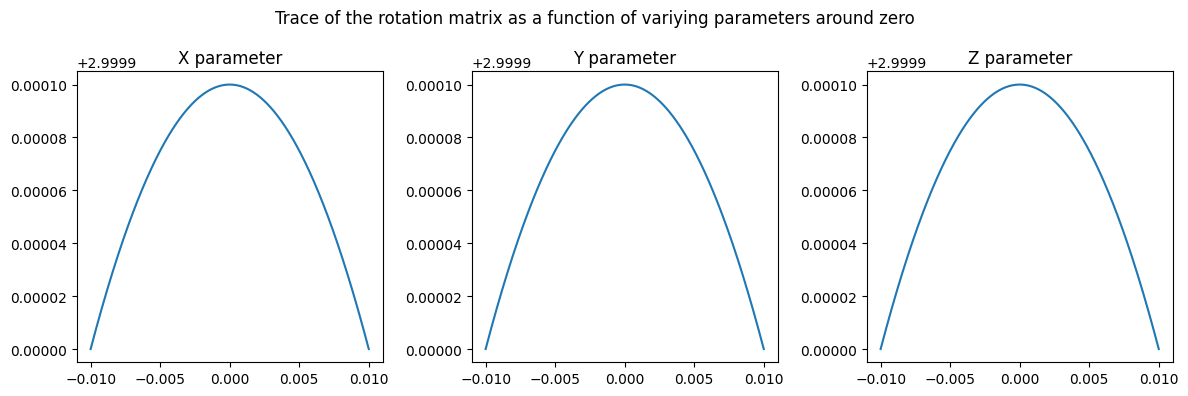

In [13]:
x0 = torch.zeros(3)
t_range = np.linspace(-0.01, 0.01, 10000)
fx = np.array([ torch.trace(my_rotation_from_vector(torch.tensor([t, 0, 0], dtype=torch.float64))) for t in t_range ])
fy = np.array([ torch.trace(my_rotation_from_vector(torch.tensor([0, t, 0], dtype=torch.float64))) for t in t_range ])
fz = np.array([ torch.trace(my_rotation_from_vector(torch.tensor([0, 0, t], dtype=torch.float64))) for t in t_range ])
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].plot(t_range, fx); ax[0].set_title("X parameter")
ax[1].plot(t_range, fy); ax[1].set_title("Y parameter")
ax[2].plot(t_range, fz); ax[2].set_title("Z parameter")
fig.suptitle('Trace of the rotation matrix as a function of variying parameters around zero');
plt.tight_layout();

(<Figure size 1200x341.509 with 9 Axes>,
 [[<Axes: >, <Axes: >, <Axes: >], [<Axes: >, <Axes: >, <Axes: >]])

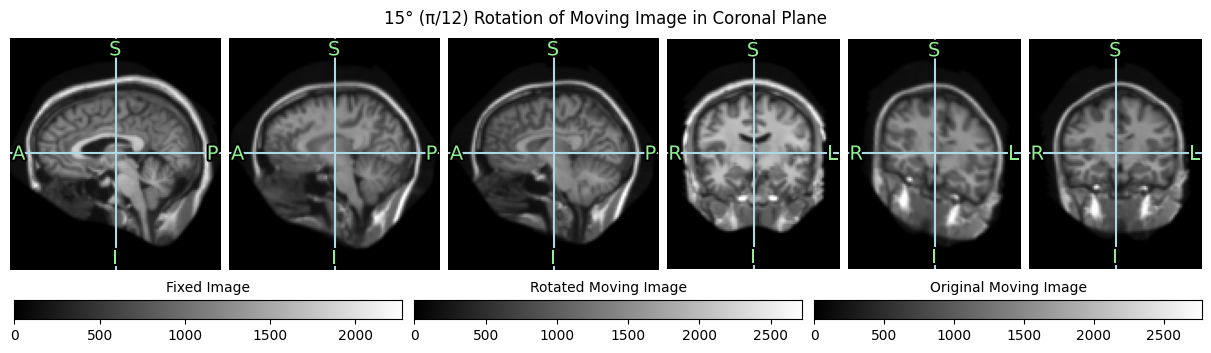

In [14]:
theta = torch.tensor([0.0, torch.pi/12, 0.0], dtype=torch.float32)
R = my_rotation_from_vector(theta)
A = R
b = torch.zeros(3, dtype=torch.float32)
T_resampled_rot = my_transform_image_pytorch(T_fix, T_mov, A, b)
img_resampled_rot = my_torch_to_sitk(T_resampled_rot, img_fix)

view_sitk(
    img_fix,
    img_resampled_rot,
    img_mov,
    name=['Fixed Image', 'Rotated Moving Image', 'Original Moving Image'],
    layout='ttt',
    width=12,
    cmap='gray',
    title='15° (π/12) Rotation of Moving Image in Coronal Plane'
)

However, the result is not a true rotation in the coronal plane, but an affine transformation that combines some rotation and some stretching. This is because the PyTorch coordinate space with image corners assigned coordinates [-1,-1,-1] and [1,1,1] has a different aspect ratio from the scanner physical space. The PyTorch coordinate space has voxel spacing $[2/D,2/H,2/W]$ where $D,H,W$ are the 3D image dimensions, whereas the actual medical images in this dataset have voxel spacing on $2.0$ in each dimension. So a rotation in PyTorch coordinate space does not correpond to rotation in physical space, and vice versa.

We need to take a PyTorch tensor representing a rotation matrix $\mathbf{R}$, and transform to an affine matrix $\mathbf{A}$ so that the transformation $\mathbf{w}=\mathbf{A}\mathbf{x}$ in PyTorch coordinates corresponds to the transformation $\mathbf{z}=\mathbf{R}\mathbf{y}$ in physical coordinates, where $\mathbf{y}$ are the physical coordinates corresponding to the PyTorch coordinates $\mathbf{x}$ and $\mathbf{z}$ are the physical coordinates corresponding to the PyTorch coordinates $\mathbf{w}$, as illustrated in the diagram below.

<p style="text-align: center;"><img width="60%" src="https://raw.githubusercontent.com/pyushkevich/upenn_be5370_utils/main/doc/figs/rp1/torch_coord_rotation.png"></img><br>Mapping between PyTorch and physical coordinate spaces</p>

The transformation from PyTorch coordinates to physical coordinates can be computed using the function `get_pytorch_to_physical_coordinate_transform`. For a given SimpleITK image, this function returns a 3x3 matrix $\mathbf{Q}$ and a 3x1 vector $\mathbf{p}$ that describe the affine transformation between the PyTorch and physical coordiantes (dashed lines in the Figure).

We need to work out the equation for the matrix $\mathbf{A}$ (it will involve matrices $\mathbf{R}, \mathbf{Q_f}, \mathbf{Q_m}$ and their inverses).

In [15]:
def map_rotation_to_pytorch_affine(R, img_fix, img_mov):
    """
    Find an affine transformation between a fixed image and a moving image
    in PyTorch coordinates that corresponds to a rotation in physical space.

    Args:
        R:
            Rotation matrix, represented as a shape (3,3) PyTorch tensor
        img_fix:
            Fixed image for this registration, a SimpleITK image
        img_mov:
            Moving image for this registration, a SimpleITK image
    Output:
        A an affine matrix, represented as a shape (3,3) PyTorch tensor
    """
    #physical transforms
    Qf, pf = get_pytorch_to_physical_coordinate_transform(img_fix)
    Qm, pm = get_pytorch_to_physical_coordinate_transform(img_mov)

    #map rotation to PyTorch coordinates
    Qf_inv = torch.tensor(np.linalg.inv(Qf), dtype=torch.float32)
    Qm_t = torch.tensor(Qm, dtype=torch.float32)
    R_t = torch.tensor(R, dtype=torch.float32)
    pf_t = torch.tensor(pf, dtype=torch.float32)
    pm_t = torch.tensor(pm, dtype=torch.float32)

    #linear part
    A = Qf_inv @ R_t @ Qm_t

    #translation part
    b = Qf_inv @ (R_t @ pm_t - pf_t)

    return A, b

/tmp/ipython-input-2174672611.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  R_t = torch.tensor(R, dtype=torch.float32)
/tmp/ipython-input-1028575839.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  T_A = torch.tensor(A, dtype=torch.float32)
/tmp/ipython-input-1028575839.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  T_b = torch.tensor(b, dtype=torch.float32)


(<Figure size 1200x341.509 with 9 Axes>,
 [[<Axes: >, <Axes: >, <Axes: >], [<Axes: >, <Axes: >, <Axes: >]])

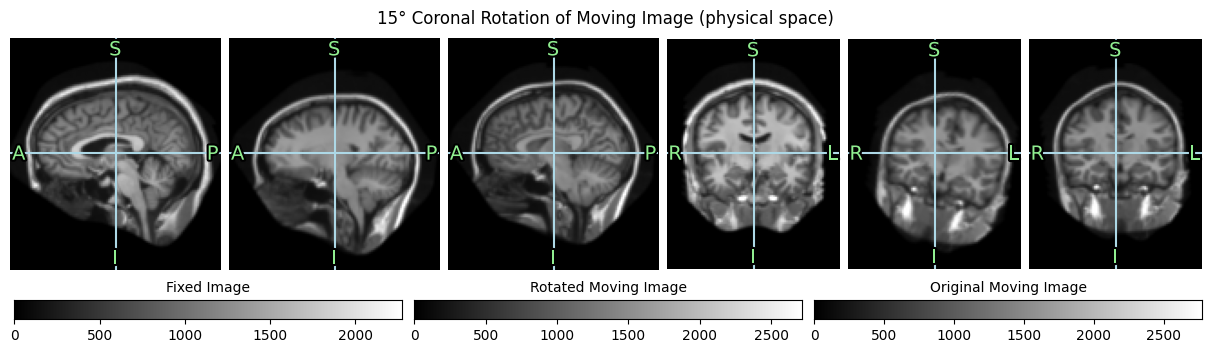

In [16]:
#15° rotation in the coronal plane
theta = torch.pi / 12  # 15 degrees
R_phys = my_rotation_from_vector(torch.tensor([0.0, theta, 0.0], dtype=torch.float32))  # coronal plane = Y-axis

#map rotation to PyTorch affine
A, b = map_rotation_to_pytorch_affine(R_phys, img_fix, img_mov)

T_A = torch.tensor(A, dtype=torch.float32)
T_b = torch.tensor(b, dtype=torch.float32)

#affine transform to the moving image
T_resampled_rot = my_transform_image_pytorch(T_fix, T_mov, T_A, T_b)
img_resampled_rot = my_torch_to_sitk(T_resampled_rot, img_fix)
view_sitk(
    img_fix,
    img_resampled_rot,
    img_mov,
    name=['Fixed Image', 'Rotated Moving Image', 'Original Moving Image'],
    layout='ttt',
    width=12,
    cmap='gray',
    title='15° Coronal Rotation of Moving Image (physical space)'
)

# Step 5. Affine Registration in PyTorch

In this step, we will implement affine registration. Note that this step does not use the rotation parametrization function from Step 4; that function will be used for rigid registration, which is one of the extension options in Step 6.

## Task 5A. Objective Function for Affine Registration

This function will use `my_transform_image_pytorch` to apply an affine transformation to the moving image, and will compute the sum of squared differences metric between the fixed image and the transformed moving image. This function will serve as the *objective function* for numerical optimization. By minimizing the intensity difference between the fixed image and resampled moving image as a function of the registration parameters $\mathbf{A}$ and $\mathbf{b}$, we will perform affine registration.

* To further avoid very large numbers and account for large shifts in image intensity, the function provides an option to z-transform the images (subtract the mean and divide by the standard deviation) before computing the metric


In [17]:

def my_affine_objective_ssd(T_fix, T_mov, T_A, T_b, z_transform=False):
    """
    Objective function for affine registration using the squared sum of differences (SSD) metric.

    Args:
        T_fix: Fixed (reference) image, a tensor of shape (1,C,Df,Hf,Wf)
        T_mov: Moving image, a tensor of shape (1,C,Dm,Hm,Wm)
        T_A: Affine matrix in PyTorch coordinate space, a tensor of shape (3,3)
        T_b: Translation vector in PyTorch coordinate space, a tensor of shape (3)
        z_transform: Whether to z-transform the image intensities before SSD computation.
    Output:
        Returns a singleton PyTorch tensor storing the value of the SSD metric.
    """
    T_mov_transformed = my_transform_image_pytorch(T_fix, T_mov, T_A, T_b)

    # Optionally z-transform intensities (zero mean, unit variance)
    if z_transform:
        T_fix = (T_fix - T_fix.mean()) / (T_fix.std() + 1e-8)
        T_mov_transformed = (T_mov_transformed - T_mov_transformed.mean()) / (T_mov_transformed.std() + 1e-8)

    # Compute squared differences
    diff = T_fix - T_mov_transformed
    ssd = torch.sum(diff * diff) / diff.numel()  # Normalize by number of voxels

    return ssd


The next code box calls this function using the identity transform and using the transform computed in ITK-SNAP

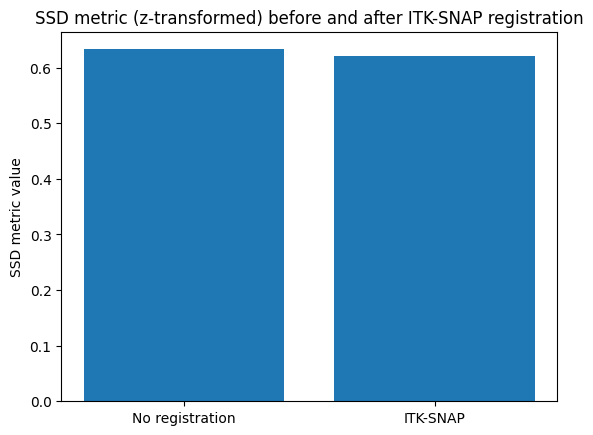

In [19]:
# Identity transform
T_A_id, T_b_id = (torch.tensor(x, dtype=T_fix.dtype) for x in (np.eye(3), np.zeros(3)))
ssd_id = my_affine_objective_ssd(T_fix, T_mov, T_A_id, T_b_id, z_transform=True)

# Transform from ITK-SNAP
#/content/drive/MyDrive/Colab Notebooks/Registration/snap_affine_reslice_fx0001_mv0000.nii.gz
tran_itk = load_itksnap_transform(f'/content/drive/MyDrive/Colab Notebooks/Registration/data/snap_affine_transform_fx{id_fix}_mv{id_mov}.mat')
T_A_itk, T_b_itk = (torch.tensor(x, dtype=T_fix.dtype) for x in map_affine_sitk_to_pytorch(tran_itk, img_fix, img_mov))
ssd_itk = my_affine_objective_ssd(T_fix, T_mov, T_A_itk, T_b_itk, z_transform=True)

# Compare before and after
plt.bar(['No registration', 'ITK-SNAP'], [ssd_id.item(), ssd_itk.item()]);
plt.title('SSD metric (z-transformed) before and after ITK-SNAP registration');
plt.ylabel('SSD metric value');

In [20]:
# Create versions of the tensors T_A and T_b that track their partial derivatives
T_A_id_grad, T_b_id_grad = (torch.tensor(x, dtype=T_fix.dtype, requires_grad=True)
                            for x in (np.eye(3), np.zeros(3)))

# Compute the objective function (forward pass)
obj = my_affine_objective_ssd(T_fix, T_mov, T_A_id_grad, T_b_id_grad, z_transform=True)

# Compute the partial derivatives of the objective function with respect to
# elements of T_A_id_grad and T_b_id_grad automatically (backward pass)
obj.backward()

# Print the objective function value and partial derivatives
obj, T_A_id_grad.grad, T_b_id_grad.grad

(tensor(0.6331, grad_fn=<DivBackward0>),
 tensor([[ 1.0644,  0.2142, -0.1445],
         [ 0.2402, -0.1536,  0.2190],
         [-0.2821,  0.2247,  0.5493]]),
 tensor([-2.0024, -0.5888, -0.5040]))

In [21]:
# Create versions of the tensors T_A and T_b that track their partial derivatives
T_A_itk_grad, T_b_itk_grad = (torch.tensor(x, dtype=T_fix.dtype, requires_grad=True)
                              for x in map_affine_sitk_to_pytorch(tran_itk, img_fix, img_mov))

# Compute the objective function (forward pass)
obj = my_affine_objective_ssd(T_fix, T_mov, T_A_itk_grad, T_b_itk_grad, z_transform=True)

# Compute the partial derivatives of the objective function with respect to
# elements of T_A_id_grad and T_b_id_grad automatically (backward pass)
obj.backward()

# Print the objective function value and partial derivatives
obj, T_A_itk_grad.grad, T_b_itk_grad.grad

(tensor(0.6215, grad_fn=<DivBackward0>),
 tensor([[ 0.8691,  0.3538, -0.1933],
         [ 0.4873,  1.2678,  0.0886],
         [-0.4305,  0.0637,  0.3853]]),
 tensor([-0.5460, -1.2516,  0.9253]))

The gradient values of the affine matrix (TA) and translation vector (Tb) represent the sensitivity of the SSD objective function to changes in the affine transformation parameters. One would generally expect the gradient values in the second cell (which likely correspond to the affine transform obtained from ITK-SNAP or some optimized parameters) to be smaller than in the first cell (which may correspond to the identity or initialization) since the optimization seeks to minimize the objective, driving gradients closer to zero at a local minimum. The gradient values should not be exactly zero unless the optimization has fully converged. If the gradients remain relatively large, it could indicate the solution is not yet optimal or the objective is non-smooth. The actual results showing non-zero but smaller-than-initial gradients agree with these expectations, suggesting convergence toward an improved alignment but not full convergence. Variability in values and whether they are nearly zero also depend on image content, noise, and the complexity of the registration problem.

## Task 5B. Optimization

We need to minimize the objective function `my_affine_objective_ssd` with respect to the affine transform parameters. In the cell below, write the optimization code using two different approaches: stochastic gradient descent (`torch.optim.SGD`) and L-BFGS, a quazi-Newton method (`torch.optim.LBFGS`). Unfortunately, the PyTorch documentation for the optimization module is not always super clear, but [this gist](https://gist.github.com/tuelwer/0b52817e9b6251d940fd8e2921ec5e20) shows how to use both optimizers in a simple example.

Perform optimization using both optimizers and plot the history like in the linked example to compare convergence of the two optimizers. Optimization should be initialized with the identity transform.

* For SGD, learning rate really matters. The value `1e-5` in the linked example gives slow convergence compared to LBFGS. Instead of SGD you can also use the Adam optimizer, it should perform more robustly.

/usr/local/lib/python3.12/dist-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  loss = float(closure())


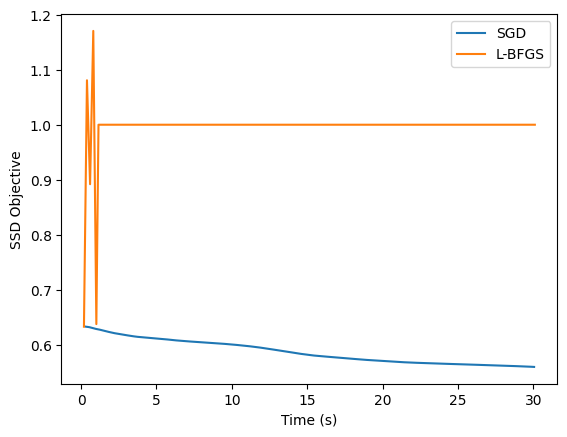

In [22]:
import torch
import time
import matplotlib.pyplot as plt

# Initialize affine parameters as identity transform
T_A_opt = torch.eye(3, dtype=T_fix.dtype, requires_grad=True)
T_b_opt = torch.zeros(3, dtype=T_fix.dtype, requires_grad=True)

def objective():
    return my_affine_objective_ssd(T_fix, T_mov, T_A_opt, T_b_opt, z_transform=True)

# SGD optimizer setup
optimizer_sgd = torch.optim.SGD([T_A_opt, T_b_opt], lr=1e-4)
sgd_losses, sgd_times = [], []
start_time = time.time()
while time.time() - start_time < 30:
    optimizer_sgd.zero_grad()
    loss = objective()
    loss.backward()
    optimizer_sgd.step()
    sgd_losses.append(loss.item())
    sgd_times.append(time.time() - start_time)

# Re-initialize parameters for L-BFGS
T_A_opt = torch.eye(3, dtype=T_fix.dtype, requires_grad=True)
T_b_opt = torch.zeros(3, dtype=T_fix.dtype, requires_grad=True)
optimizer_lbfgs = torch.optim.LBFGS([T_A_opt, T_b_opt], lr=1, max_iter=20)
lbfgs_losses, lbfgs_times = [], []
lbfgs_start = time.time()

def closure():
    optimizer_lbfgs.zero_grad()
    loss = my_affine_objective_ssd(T_fix, T_mov, T_A_opt, T_b_opt, z_transform=True)
    loss.backward()
    lbfgs_losses.append(loss.item())
    lbfgs_times.append(time.time() - lbfgs_start)
    return loss

while time.time() - lbfgs_start < 30:
    optimizer_lbfgs.step(closure)

# Plot results
plt.plot(sgd_times, sgd_losses, label='SGD')
plt.plot(lbfgs_times, lbfgs_losses, label='L-BFGS')
plt.xlabel('Time (s)')
plt.ylabel('SSD Objective')
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/upenn_be5370_utils/sitkview.py:438: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax_cb.imshow(np.linspace(vmin_adj[j], vmax_adj[j], 256)[None,:],


(<Figure size 1200x341.509 with 9 Axes>,
 [[<Axes: >, <Axes: >, <Axes: >], [<Axes: >, <Axes: >, <Axes: >]])

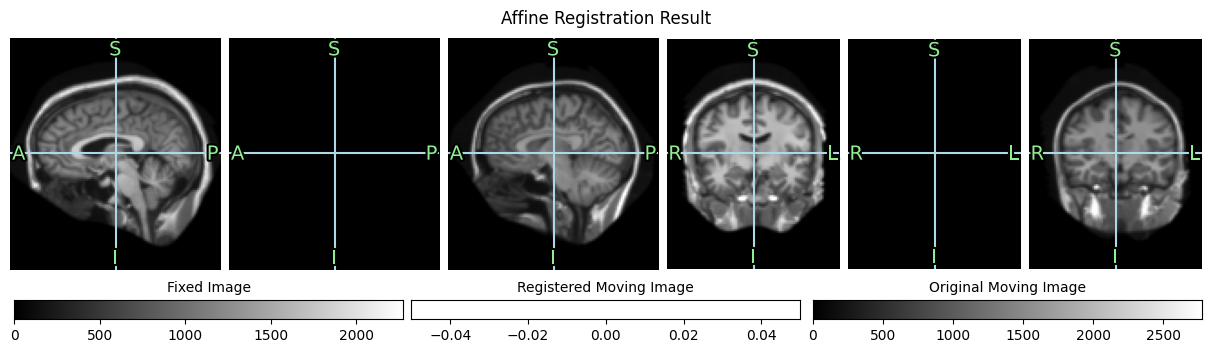

In [23]:
# Reslice moving image with optimal affine transform parameters
T_resampled_opt = my_transform_image_pytorch(T_fix, T_mov, T_A_opt.detach(), T_b_opt.detach())

# Convert tensor back to SimpleITK image for visualization
img_resampled_opt = my_torch_to_sitk(T_resampled_opt, img_fix)

# Plot fixed image, registered moving image, and original moving image side-by-side
view_sitk(
    img_fix,                       # fixed image (SimpleITK)
    img_resampled_opt,             # registered moving image (SimpleITK)
    img_mov,                      # original moving image (SimpleITK)
    name=['Fixed Image', 'Registered Moving Image', 'Original Moving Image'],
    layout='ttt',                 # layout arrangement
    width=12,
    cmap='gray',
    title='Affine Registration Result'
)
